# 10 — Визуальный отчёт по dashboard_stats

Этот ноутбук ничего тяжёлого не считает.  
Он только **читает уже готовые файлы** из `processed/dashboard_stats/` и выводит их **наглядно**:

- KPI-таблицы;
- компактные карточки;
- графики по этапам обучения;
- графики по `part`;
- сводки по числовым метрикам;
- инвентаризацию источников;
- доступность / недоступность метрик.

> Рекомендуемый порядок:
> 1. Сначала запустить `09_build_dashboard_statistics_MARTS_ONLY_V2.ipynb`
> 2. Потом открыть и запустить этот визуальный ноутбук.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


NOTEBOOK_VERSION = "VISUAL_REPORT_V1"
print("VERSION:", NOTEBOOK_VERSION)


def find_dashboard_dir() -> Path:
    candidates = [
        Path("data/processed/dashboard_stats"),
        Path("../data/processed/dashboard_stats"),
        Path("../../data/processed/dashboard_stats"),
        Path("processed/dashboard_stats"),
        Path("../processed/dashboard_stats"),
        Path("../../processed/dashboard_stats"),
    ]
    for p in candidates:
        if (p / "dashboard_kpi.parquet").exists():
            return p
    raise FileNotFoundError(
        "Не найден processed/dashboard_stats с готовыми файлами. "
        "Сначала запусти расчётный ноутбук."
    )


DASHBOARD_DIR = find_dashboard_dir()

FILES = {
    "kpi": DASHBOARD_DIR / "dashboard_kpi.parquet",
    "metric_summary": DASHBOARD_DIR / "dashboard_metric_summary.parquet",
    "part_summary": DASHBOARD_DIR / "dashboard_part_summary.parquet",
    "stage_summary": DASHBOARD_DIR / "dashboard_stage_summary.parquet",
    "source_inventory": DASHBOARD_DIR / "dashboard_source_inventory.parquet",
    "metric_availability": DASHBOARD_DIR / "dashboard_metric_availability.parquet",
}

for name, path in FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}")

print("DASHBOARD_DIR:", DASHBOARD_DIR.resolve())
print("Файлы найдены:", ", ".join(FILES.keys()))

Matplotlib is building the font cache; this may take a moment.


VERSION: VISUAL_REPORT_V1
DASHBOARD_DIR: /Users/anna/проект шар/data/processed/dashboard_stats
Файлы найдены: kpi, metric_summary, part_summary, stage_summary, source_inventory, metric_availability


## 1. Загрузка данных

In [3]:
kpi = pd.read_parquet(FILES["kpi"])
metric_summary = pd.read_parquet(FILES["metric_summary"])
part_summary = pd.read_parquet(FILES["part_summary"])
stage_summary = pd.read_parquet(FILES["stage_summary"])
source_inventory = pd.read_parquet(FILES["source_inventory"])
metric_availability = pd.read_parquet(FILES["metric_availability"])

print("kpi:", kpi.shape)
print("metric_summary:", metric_summary.shape)
print("part_summary:", part_summary.shape)
print("stage_summary:", stage_summary.shape)
print("source_inventory:", source_inventory.shape)
print("metric_availability:", metric_availability.shape)

kpi: (28, 5)
metric_summary: (40, 14)
part_summary: (7, 13)
stage_summary: (56, 25)
source_inventory: (4, 5)
metric_availability: (11, 4)


## 2. Инвентаризация источников

,source,file_name,rows_count,columns_count,size_mb
0,mart_users,mart_users.parquet,393656,28,22.551727
1,mart_questions,mart_questions.parquet,13523,20,1.007000
2,mart_topics,mart_topics.parquet,188,19,0.015323
3,mart_student_stage,mart_student_stage.parquet,56,24,0.020957


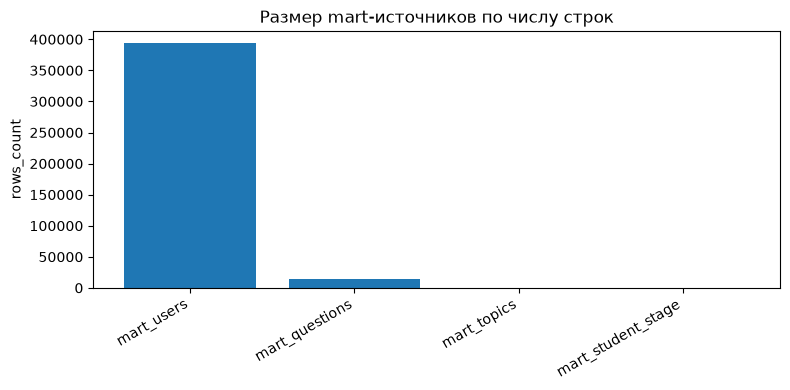

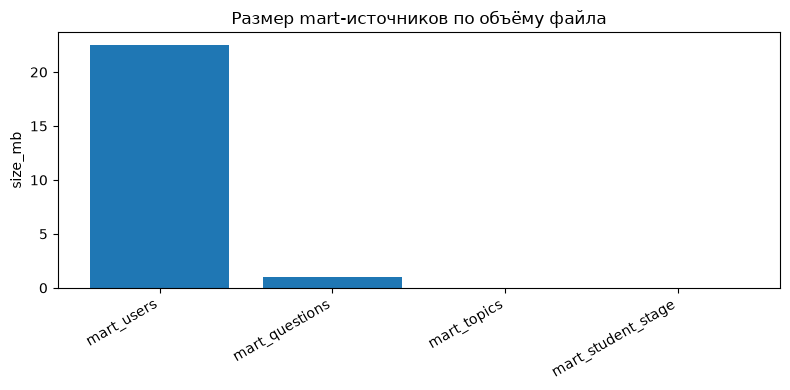

In [4]:
display(source_inventory)

plt.figure(figsize=(8, 4))
plt.bar(source_inventory["source"], source_inventory["rows_count"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("rows_count")
plt.title("Размер mart-источников по числу строк")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(source_inventory["source"], source_inventory["size_mb"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("size_mb")
plt.title("Размер mart-источников по объёму файла")
plt.tight_layout()
plt.show()

## 3. KPI — таблица и карточки

In [5]:
def format_value(value, unit):
    if pd.isna(value):
        return "—"
    if unit == "share":
        return f"{value:.2%}"
    if unit == "share_delta":
        return f"{value:+.2%}"
    if unit in {"days", "questions", "attempts", "events", "sessions", "users", "topics"}:
        if float(value).is_integer():
            return f"{int(value):,}".replace(",", " ")
        return f"{value:,.2f}".replace(",", " ")
    return f"{value:,.2f}".replace(",", " ")


display(kpi)

kpi_view = kpi.copy()
kpi_view["formatted_value"] = [
    format_value(v, u) for v, u in zip(kpi_view["value"], kpi_view["unit"])
]

for section in kpi_view["section"].dropna().unique():
    block = kpi_view[kpi_view["section"].eq(section)].copy()

    html_cards = '<div style="display:flex;flex-wrap:wrap;gap:12px;margin:8px 0 18px 0;">'
    for _, row in block.iterrows():
        html_cards += f"""
        <div style="
            min-width:240px;
            max-width:300px;
            border:1px solid #ddd;
            border-radius:10px;
            padding:12px 14px;
            box-shadow:0 1px 4px rgba(0,0,0,0.06);
        ">
            <div style="font-size:12px;color:#666;text-transform:uppercase;">
                {row['section']}
            </div>
            <div style="font-size:15px;font-weight:600;margin-top:6px;">
                {row['metric']}
            </div>
            <div style="font-size:28px;font-weight:700;margin-top:8px;">
                {row['formatted_value']}
            </div>
            <div style="font-size:12px;color:#666;margin-top:8px;line-height:1.35;">
                {row['description']}
            </div>
        </div>
        """
    html_cards += "</div>"

    display(HTML(f"<h3>{section}</h3>"))
    display(HTML(html_cards))

,section,metric,value,unit,description
0,volume,users_count,3.936560e+05,users,Количество пользователей в mart_users.
1,volume,sessions_count,5.945418e+06,sessions,Сумма sessions_count по пользователям.
2,volume,question_attempts,9.927130e+07,attempts,Сумма вопросов/попыток по пользователям.
3,volume,lecture_events,1.959032e+06,events,Сумма lecture events по пользователям.
4,volume,events_count,1.012303e+08,events,Сумма всех событий по пользователям.
5,quality,overall_accuracy,6.572355e-01,share,Взвешенная accuracy = correct_answers / questi...
6,users,mean_sessions_per_user,1.510308e+01,sessions,Среднее число сессий на пользователя.
7,users,median_sessions_per_user,2.000000e+00,sessions,Медианное число сессий на пользователя.
8,users,mean_unique_questions_per_user,2.206674e+02,questions,Среднее число уникальных вопросов на пользоват...
9,users,median_unique_questions_per_user,4.000000e+01,questions,Медианное число уникальных вопросов на пользов...


## 4. KPI — компактная сводная таблица

In [6]:
kpi_pivot = (
    kpi.assign(
        formatted_value=[
            format_value(v, u) for v, u in zip(kpi["value"], kpi["unit"])
        ]
    )
    .pivot_table(
        index="metric",
        columns="section",
        values="formatted_value",
        aggfunc="first",
    )
    .reset_index()
)

display(kpi_pivot)

section,metric,funnel,quality,questions,sessions,topics,users,volume
0,content_gap_share,NaN,NaN,NaN,NaN,1.60%,NaN,NaN
1,content_gap_topics,NaN,NaN,NaN,NaN,3,NaN,NaN
2,events_count,NaN,NaN,NaN,NaN,NaN,NaN,101 230 332
3,lecture_events,NaN,NaN,NaN,NaN,NaN,NaN,1 959 032
4,mean_learning_duration_days,NaN,NaN,NaN,NaN,NaN,59.48,NaN
5,mean_question_difficulty,NaN,NaN,29.05%,NaN,NaN,NaN,NaN
6,mean_sessions_per_user,NaN,NaN,NaN,NaN,NaN,15.10,NaN
7,mean_unique_questions_per_user,NaN,NaN,NaN,NaN,NaN,220.67,NaN
8,mean_user_avg_questions_per_session,NaN,NaN,NaN,20.42,NaN,NaN,NaN
9,median_learning_duration_days,NaN,NaN,NaN,NaN,NaN,4.33,NaN


## 5. Воронка и метрики по этапам

,aggregation_level,stage_order,stage,stage_min_question,stage_max_question,part,students_count,answers_count,accuracy,median_elapsed_time,mean_elapsed_time,elapsed_time_observations,lectures_count,lecture_students_count,students_without_lectures,lecture_rate,lectures_per_student,explanation_rate,explanation_observations,median_error_streak,sessions_count,avg_questions_per_session,small_sample_flag,sample_size_status,reach_from_stage_1_share
0,stage,1,1–10,1,10,<NA>,393656,3928411,0.507141,21232.034384,24322.908859,3535905,2159,2032,391624,0.005162,0.005484,0.081842,3535905,0,475856,8.255462,False,ok,1.000000
1,stage,2,11–20,11,20,<NA>,390687,3672430,0.502691,19999.546087,22313.372812,3672430,19382,18128,372559,0.046400,0.049610,0.516852,3672430,0,482973,7.603800,False,ok,0.992458
2,stage,3,21–50,21,50,<NA>,332257,7224103,0.585427,20028.406350,24285.175886,7224103,86141,65726,266531,0.197817,0.259260,0.735129,7224103,0,682931,10.578086,False,ok,0.844029
3,stage,4,51–100,51,100,<NA>,174074,7253473,0.644936,19999.712039,24240.644575,7253473,144372,83470,90604,0.479509,0.829371,0.942556,7253473,0,633421,11.451267,False,ok,0.442198
4,stage,5,101–200,101,200,<NA>,123379,10137455,0.654587,20488.588795,25256.813361,10137455,241606,81703,41676,0.662212,1.958242,0.956895,10137455,0,780394,12.990175,False,ok,0.313418
5,stage,6,201–500,201,500,<NA>,84659,18144113,0.664490,21008.151010,26044.997359,18144113,482527,65614,19045,0.775039,5.699654,0.977185,18144113,0,1248021,14.538307,False,ok,0.215058
6,stage,7,501+,501,<NA>,<NA>,44266,48911315,0.691182,21175.349982,25884.751293,48911315,982845,36981,7285,0.835427,22.203158,0.979732,48911315,0,2716513,18.005183,False,ok,0.112448


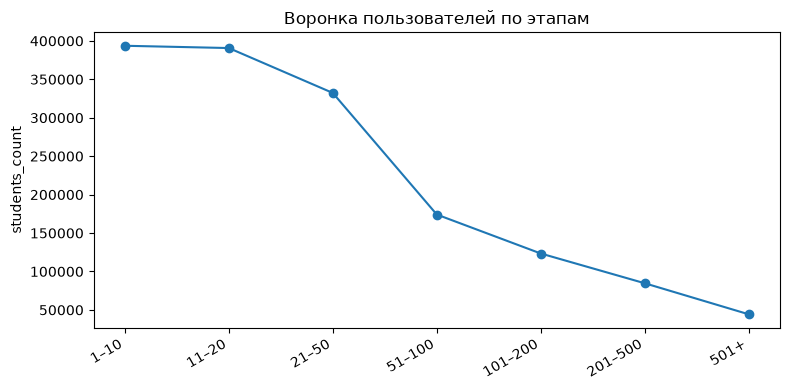

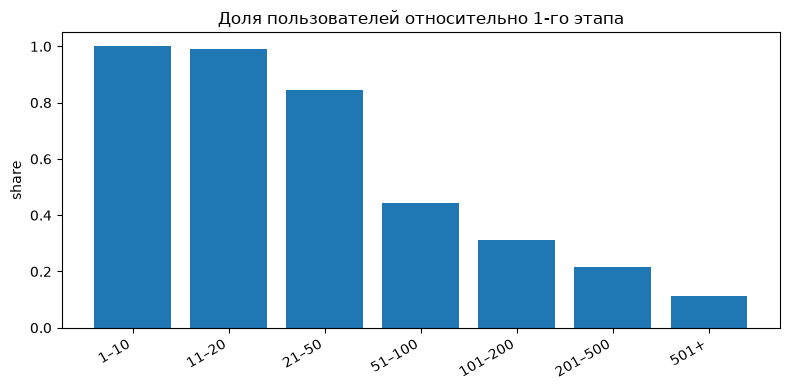

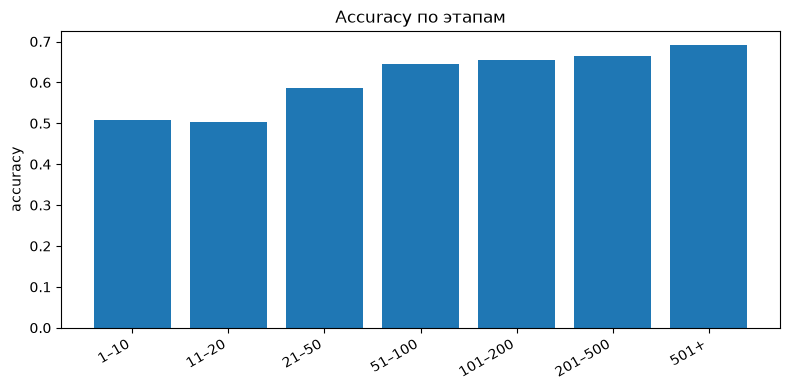

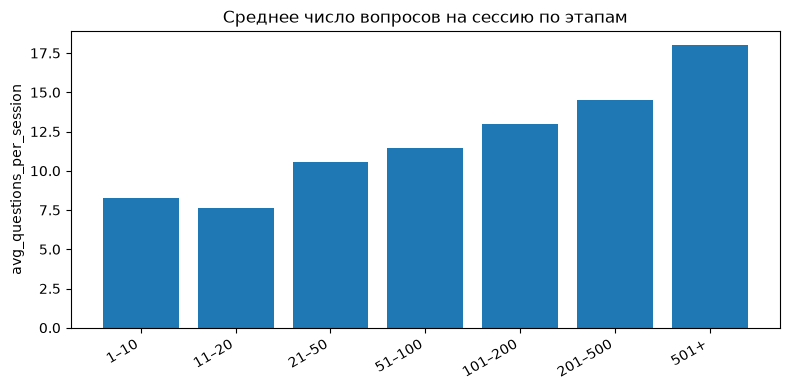

In [7]:
stage_only = stage_summary[stage_summary["aggregation_level"].eq("stage")].copy()
stage_only = stage_only.sort_values("stage_order")

display(stage_only)

plt.figure(figsize=(8, 4))
plt.plot(stage_only["stage"], stage_only["students_count"], marker="o")
plt.xticks(rotation=30, ha="right")
plt.ylabel("students_count")
plt.title("Воронка пользователей по этапам")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(stage_only["stage"], stage_only["reach_from_stage_1_share"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("share")
plt.title("Доля пользователей относительно 1-го этапа")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(stage_only["stage"], stage_only["accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("accuracy")
plt.title("Accuracy по этапам")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(stage_only["stage"], stage_only["avg_questions_per_session"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("avg_questions_per_session")
plt.title("Среднее число вопросов на сессию по этапам")
plt.tight_layout()
plt.show()

## 6. Разрез по part

,part,questions_catalog,questions_seen,attempts,question_user_pairs,correct_answers,incorrect_answers,weighted_accuracy,weighted_difficulty,mean_question_accuracy,median_question_elapsed_time,median_attempts_per_question,questions_enough_attempts
0,1,992,992,7454570,6735835,5553896,1900674,0.745032,0.254968,0.815104,21000.000000,5948.0,642
1,2,1647,1647,18743404,15706116,13283339,5460065,0.708694,0.291306,0.745296,17000.000000,9793.0,1602
2,3,1562,1562,8639907,7706350,6060514,2579393,0.701456,0.298544,0.744598,24000.000000,4951.0,1238
3,4,1439,1439,8067676,7279636,5090684,2976992,0.630998,0.369002,0.724918,24000.000000,4517.0,1040
4,5,5511,5511,40908153,35675224,24957570,15950583,0.610088,0.389912,0.666119,20000.000000,4617.0,5372
5,6,1212,1212,10501472,9064117,7029563,3471909,0.669388,0.330612,0.699596,29860.294118,5179.0,1207
6,7,1160,1160,4956118,4699753,3269061,1687057,0.659601,0.340399,0.717958,54642.288889,2762.0,1070


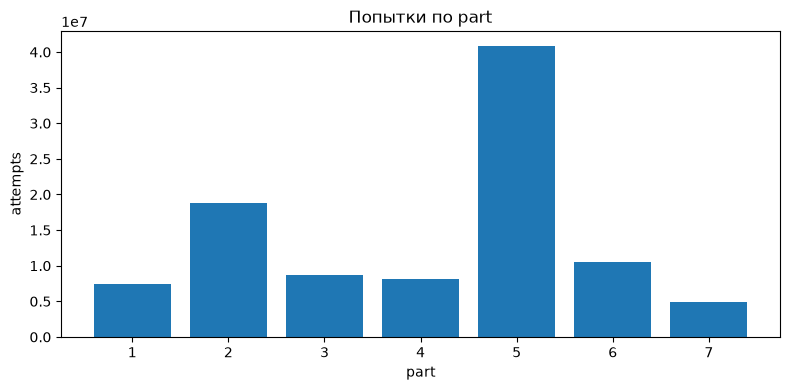

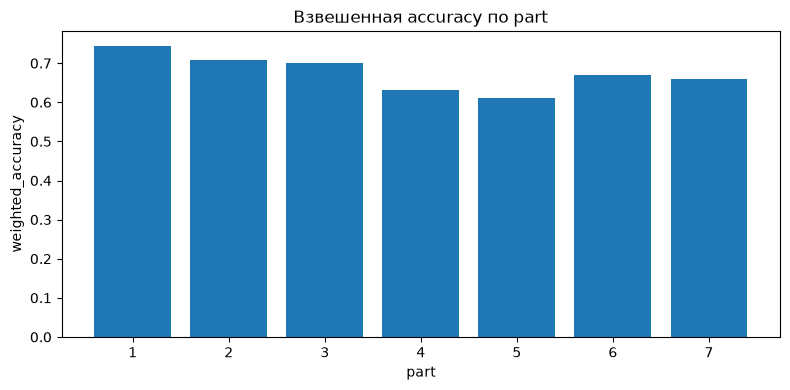

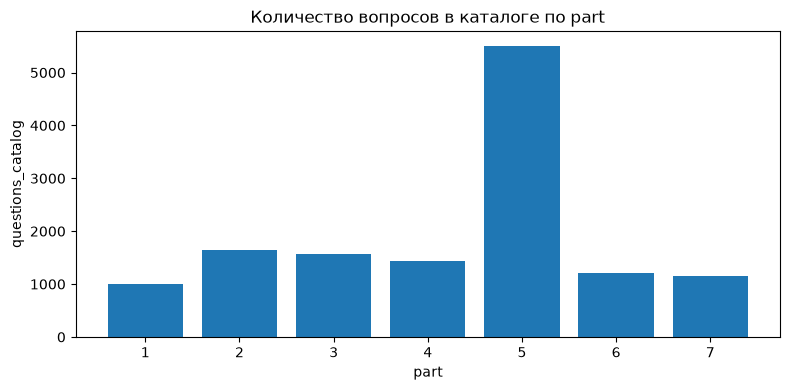

In [8]:
display(part_summary)

plt.figure(figsize=(8, 4))
plt.bar(part_summary["part"].astype(str), part_summary["attempts"])
plt.xlabel("part")
plt.ylabel("attempts")
plt.title("Попытки по part")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(part_summary["part"].astype(str), part_summary["weighted_accuracy"])
plt.xlabel("part")
plt.ylabel("weighted_accuracy")
plt.title("Взвешенная accuracy по part")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(part_summary["part"].astype(str), part_summary["questions_catalog"])
plt.xlabel("part")
plt.ylabel("questions_catalog")
plt.title("Количество вопросов в каталоге по part")
plt.tight_layout()
plt.show()

## 7. Сводка по метрикам — таблица

In [9]:
display(metric_summary)

summary_short = metric_summary[
    [
        "entity_level",
        "metric",
        "unit",
        "n",
        "mean",
        "median",
        "p75",
        "p90",
        "p95",
        "max",
        "description",
    ]
].copy()

display(summary_short)

,entity_level,metric,unit,description,n,mean,stddev,min,p25,median,p75,p90,p95,max
0,user,questions_count,attempts,Количество вопросных попыток пользователя.,393656,2.521778e+02,7.347211e+02,1.000000,30.000000,41.000000,1.540000e+02,5.790000e+02,1.150000e+03,1.760900e+04
1,user,lectures_count,events,Количество lecture events пользователя.,393656,4.976507e+00,1.596479e+01,0.000000,0.000000,0.000000,2.000000e+00,1.300000e+01,2.800000e+01,3.970000e+02
2,user,events_count,events,Количество всех событий пользователя.,393656,2.571543e+02,7.475509e+02,1.000000,30.000000,41.000000,1.570000e+02,5.920000e+02,1.180000e+03,1.791700e+04
3,user,sessions_count,sessions,Количество сессий пользователя.,393656,1.510308e+01,4.454433e+01,1.000000,1.000000,2.000000,1.000000e+01,3.600000e+01,6.900000e+01,2.374000e+03
4,user,unique_questions,questions,Уникальные вопросы пользователя.,393656,2.206674e+02,5.899140e+02,1.000000,29.000000,40.000000,1.420000e+02,5.150000e+02,1.019000e+03,1.121800e+04
5,user,unique_parts,parts,Уникальные part пользователя.,393656,4.639320e+00,2.309854e+00,1.000000,2.000000,5.000000,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00
6,user,unique_tags,topics,Уникальные tags пользователя.,393656,6.173028e+01,4.357786e+01,1.000000,34.000000,43.000000,8.500000e+01,1.330000e+02,1.570000e+02,1.880000e+02
7,user,accuracy,share,Accuracy пользователя.,393656,5.451833e-01,1.633780e-01,0.000000,0.433580,0.570306,6.669302e-01,7.361547e-01,7.741746e-01,1.000000e+00
8,user,progress_20,share_delta,last_20_accuracy - first_20_accuracy.,209268,8.813483e-02,2.198800e-01,-0.900000,-0.050000,0.100000,2.498244e-01,3.500000e-01,4.499808e-01,9.500000e-01
9,user,median_question_elapsed_time,ms,Медианное время ответа пользователя.,393569,2.121571e+04,6.692793e+03,0.000000,17547.789983,20061.912720,2.399983e+04,2.864775e+04,3.246410e+04,3.000000e+05


,entity_level,metric,unit,n,mean,median,p75,p90,p95,max,description
0,user,questions_count,attempts,393656,2.521778e+02,41.000000,1.540000e+02,5.790000e+02,1.150000e+03,1.760900e+04,Количество вопросных попыток пользователя.
1,user,lectures_count,events,393656,4.976507e+00,0.000000,2.000000e+00,1.300000e+01,2.800000e+01,3.970000e+02,Количество lecture events пользователя.
2,user,events_count,events,393656,2.571543e+02,41.000000,1.570000e+02,5.920000e+02,1.180000e+03,1.791700e+04,Количество всех событий пользователя.
3,user,sessions_count,sessions,393656,1.510308e+01,2.000000,1.000000e+01,3.600000e+01,6.900000e+01,2.374000e+03,Количество сессий пользователя.
4,user,unique_questions,questions,393656,2.206674e+02,40.000000,1.420000e+02,5.150000e+02,1.019000e+03,1.121800e+04,Уникальные вопросы пользователя.
5,user,unique_parts,parts,393656,4.639320e+00,5.000000,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,Уникальные part пользователя.
6,user,unique_tags,topics,393656,6.173028e+01,43.000000,8.500000e+01,1.330000e+02,1.570000e+02,1.880000e+02,Уникальные tags пользователя.
7,user,accuracy,share,393656,5.451833e-01,0.570306,6.669302e-01,7.361547e-01,7.741746e-01,1.000000e+00,Accuracy пользователя.
8,user,progress_20,share_delta,209268,8.813483e-02,0.100000,2.498244e-01,3.500000e-01,4.499808e-01,9.500000e-01,last_20_accuracy - first_20_accuracy.
9,user,median_question_elapsed_time,ms,393569,2.121571e+04,20061.912720,2.399983e+04,2.864775e+04,3.246410e+04,3.000000e+05,Медианное время ответа пользователя.


## 8. Сводка по метрикам — отбор самых полезных

,entity_level,metric,unit,description,n,mean,stddev,min,p25,median,p75,p90,p95,max
19,question,accuracy,share,Accuracy вопроса.,13523,7.094601e-01,1.644864e-01,0.000000,0.609343,0.734270,8.352426e-01,9.031883e-01,9.337482e-01,1.000000e+00
17,question,attempts,attempts,Количество попыток по вопросу.,13523,7.340923e+03,1.145593e+04,1.000000,1772.000000,4732.000000,8.563000e+03,1.588800e+04,2.250500e+04,2.136050e+05
20,question,difficulty,share,1 - accuracy.,13523,2.905399e-01,1.644864e-01,0.000000,0.164618,0.265621,3.907595e-01,5.231294e-01,6.086431e-01,1.000000e+00
32,topic,accuracy,share,Accuracy темы.,188,6.660519e-01,8.157128e-02,0.385725,0.620285,0.678187,7.143975e-01,7.575748e-01,7.962338e-01,8.639452e-01
39,topic,accuracy_difference,share_delta,Разница after lecture - without lecture.,151,4.573487e-02,6.695383e-02,-0.065984,0.002053,0.027724,7.391938e-02,1.361097e-01,1.807341e-01,4.030665e-01
30,topic,attempts,attempts,Число попыток темы.,188,1.250916e+06,2.481004e+06,3367.000000,329868.000000,531654.000000,1.116226e+06,2.206504e+06,3.453486e+06,1.881434e+07
33,topic,difficulty,share,1 - accuracy темы.,188,3.339481e-01,8.157128e-02,0.136055,0.285603,0.321813,3.797146e-01,4.470332e-01,4.796786e-01,6.142752e-01
31,topic,students_count,users,Число пользователей темы.,188,1.292580e+05,7.881620e+04,2626.000000,70156.000000,123620.000000,1.774860e+05,2.330970e+05,2.694120e+05,3.574300e+05
7,user,accuracy,share,Accuracy пользователя.,393656,5.451833e-01,1.633780e-01,0.000000,0.433580,0.570306,6.669302e-01,7.361547e-01,7.741746e-01,1.000000e+00
13,user,avg_questions_per_session,questions,Среднее число вопросов за сессию пользователя.,393656,2.041635e+01,1.156979e+01,1.000000,12.223868,17.688874,2.972429e+01,3.131287e+01,3.999963e+01,4.530000e+02


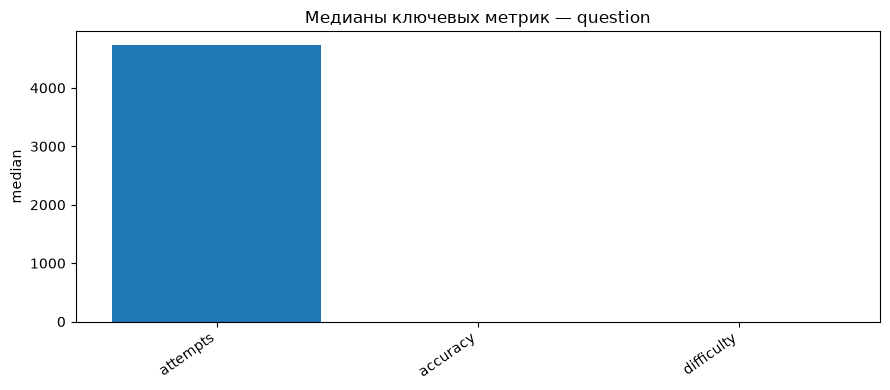

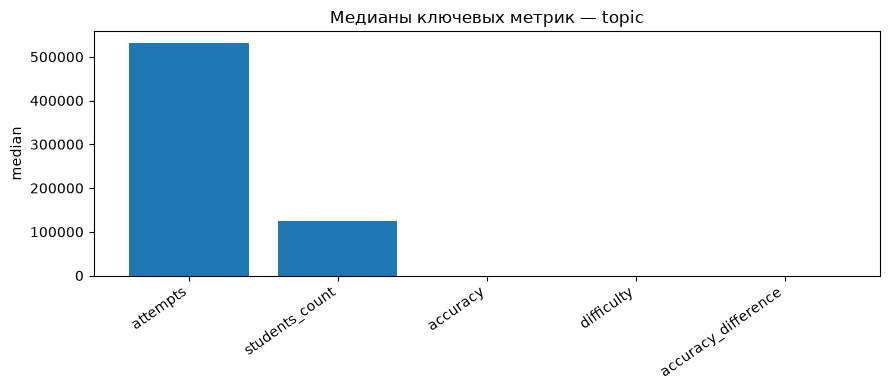

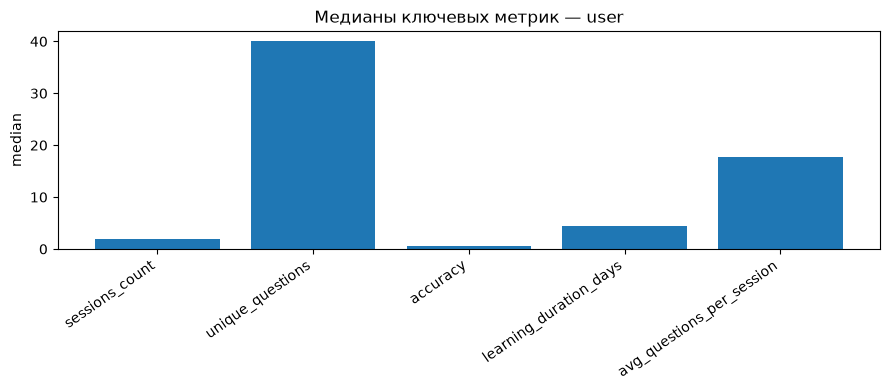

In [10]:
focus_metrics = [
    "sessions_count",
    "unique_questions",
    "accuracy",
    "learning_duration_days",
    "avg_questions_per_session",
    "attempts",
    "difficulty",
    "students_count",
    "accuracy_difference",
]

focus = metric_summary[
    metric_summary["metric"].isin(focus_metrics)
].copy()

display(focus.sort_values(["entity_level", "metric"]))


for entity_level in sorted(focus["entity_level"].dropna().unique()):
    block = focus[focus["entity_level"].eq(entity_level)].copy()

    plt.figure(figsize=(9, 4))
    plt.bar(block["metric"], block["median"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("median")
    plt.title(f"Медианы ключевых метрик — {entity_level}")
    plt.tight_layout()
    plt.show()

## 9. Какие метрики доступны / недоступны

,metric,available,source,comment
0,users_count,True,mart_users,COUNT(*) по пользователям.
1,sessions_count,True,mart_users.sessions_count,Суммарное число сессий можно получить без собы...
2,avg_questions_per_session,True,mart_users / mart_student_stage,Есть на уровне пользователя и этапа.
3,unique_questions_per_user,True,mart_users.unique_questions,Можно строить распределение по пользователям.
4,unique_questions_catalog,True,mart_questions.question_id,Одна строка = один question_id.
5,question_accuracy_difficulty,True,mart_questions,Есть готовые accuracy/difficulty и количество ...
6,topic_statistics,True,mart_topics,"Есть attempts, students, accuracy, lectures и ..."
7,stage_funnel,True,mart_student_stage,Есть students_count по этапам.
8,user_learning_duration,True,mart_users.learning_duration_days,"Это span всей активности пользователя, не отде..."
9,session_duration,False,,В текущих mart нет start/end или duration отде...


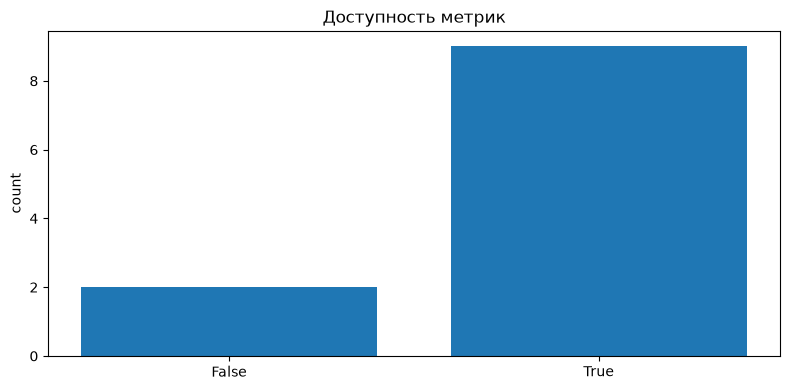

,metric,available,source,comment
2,avg_questions_per_session,True,mart_users / mart_student_stage,Есть на уровне пользователя и этапа.
5,question_accuracy_difficulty,True,mart_questions,Есть готовые accuracy/difficulty и количество ...
1,sessions_count,True,mart_users.sessions_count,Суммарное число сессий можно получить без собы...
7,stage_funnel,True,mart_student_stage,Есть students_count по этапам.
6,topic_statistics,True,mart_topics,"Есть attempts, students, accuracy, lectures и ..."
4,unique_questions_catalog,True,mart_questions.question_id,Одна строка = один question_id.
3,unique_questions_per_user,True,mart_users.unique_questions,Можно строить распределение по пользователям.
8,user_learning_duration,True,mart_users.learning_duration_days,"Это span всей активности пользователя, не отде..."
0,users_count,True,mart_users,COUNT(*) по пользователям.
10,questions_per_individual_session_distribution,False,,Есть только avg_questions_per_session пользова...


In [11]:
display(metric_availability)

available = metric_availability.copy()
available["available_num"] = available["available"].astype(int)

plt.figure(figsize=(8, 4))
counts = available["available"].value_counts().sort_index()
plt.bar(["False", "True"], [counts.get(False, 0), counts.get(True, 0)])
plt.ylabel("count")
plt.title("Доступность метрик")
plt.tight_layout()
plt.show()

display(
    metric_availability.sort_values(["available", "metric"], ascending=[False, True])
)

## 10. Быстрые витрины для чтения глазами

In [12]:
print("TOP metrics by p90:")
display(
    metric_summary.sort_values("p90", ascending=False).head(20)
)

print("TOP topics/questions-like metrics with biggest max:")
display(
    metric_summary.sort_values("max", ascending=False).head(20)
)

print("Part summary sorted by attempts:")
display(
    part_summary.sort_values("attempts", ascending=False)
)

print("Stage summary (stage level only):")
display(
    stage_only[
        [
            "stage_order",
            "stage",
            "students_count",
            "answers_count",
            "accuracy",
            "lecture_rate",
            "sessions_count",
            "avg_questions_per_session",
        ]
    ]
)

TOP metrics by p90:


,entity_level,metric,unit,description,n,mean,stddev,min,p25,median,p75,p90,p95,max
30,topic,attempts,attempts,Число попыток темы.,188,1.250916e+06,2.481004e+06,3367.0,329868.000000,531654.000000,1.116226e+06,2.206504e+06,3.453486e+06,1.881434e+07
31,topic,students_count,users,Число пользователей темы.,188,1.292580e+05,7.881620e+04,2626.0,70156.000000,123620.000000,1.774860e+05,2.330970e+05,2.694120e+05,3.574300e+05
11,user,median_time_between_events,ms,Медианный интервал между событиями пользователя.,393569,1.374763e+05,4.034392e+07,0.0,21093.009392,28890.451741,4.004846e+04,5.581071e+04,7.031099e+04,1.972808e+10
34,topic,median_elapsed_time,ms,Медианное время ответа по теме.,188,2.542731e+04,1.000180e+04,17000.0,20354.079621,21633.857191,2.417612e+04,4.708609e+04,4.750912e+04,4.962423e+04
22,question,mean_elapsed_time,ms,Среднее время ответа по вопросу.,13523,2.665457e+04,1.110529e+04,1000.0,20156.742735,23351.654578,2.884091e+04,3.826568e+04,5.485516e+04,9.221356e+04
21,question,median_elapsed_time,ms,Медианное время ответа по вопросу.,13523,2.445245e+04,1.090850e+04,1000.0,18000.000000,22006.724962,2.599974e+04,3.488527e+04,5.208128e+04,8.900000e+04
10,user,mean_question_elapsed_time,ms,Среднее время ответа пользователя.,393569,2.389367e+04,7.965715e+03,0.0,19114.217722,22719.279394,2.731395e+04,3.303899e+04,3.763230e+04,2.308333e+05
9,user,median_question_elapsed_time,ms,Медианное время ответа пользователя.,393569,2.121571e+04,6.692793e+03,0.0,17547.789983,20061.912720,2.399983e+04,2.864775e+04,3.246410e+04,3.000000e+05
36,topic,lecture_views,events,Число просмотров лекций темы.,188,1.042038e+04,1.100931e+04,0.0,1044.000000,7756.000000,1.683400e+04,2.461700e+04,3.080500e+04,5.886900e+04
17,question,attempts,attempts,Количество попыток по вопросу.,13523,7.340923e+03,1.145593e+04,1.0,1772.000000,4732.000000,8.563000e+03,1.588800e+04,2.250500e+04,2.136050e+05


TOP topics/questions-like metrics with biggest max:


,entity_level,metric,unit,description,n,mean,stddev,min,p25,median,p75,p90,p95,max
11,user,median_time_between_events,ms,Медианный интервал между событиями пользователя.,393569,1.374763e+05,4.034392e+07,0.0,21093.009392,28890.451741,4.004846e+04,5.581071e+04,7.031099e+04,1.972808e+10
30,topic,attempts,attempts,Число попыток темы.,188,1.250916e+06,2.481004e+06,3367.0,329868.000000,531654.000000,1.116226e+06,2.206504e+06,3.453486e+06,1.881434e+07
31,topic,students_count,users,Число пользователей темы.,188,1.292580e+05,7.881620e+04,2626.0,70156.000000,123620.000000,1.774860e+05,2.330970e+05,2.694120e+05,3.574300e+05
9,user,median_question_elapsed_time,ms,Медианное время ответа пользователя.,393569,2.121571e+04,6.692793e+03,0.0,17547.789983,20061.912720,2.399983e+04,2.864775e+04,3.246410e+04,3.000000e+05
10,user,mean_question_elapsed_time,ms,Среднее время ответа пользователя.,393569,2.389367e+04,7.965715e+03,0.0,19114.217722,22719.279394,2.731395e+04,3.303899e+04,3.763230e+04,2.308333e+05
17,question,attempts,attempts,Количество попыток по вопросу.,13523,7.340923e+03,1.145593e+04,1.0,1772.000000,4732.000000,8.563000e+03,1.588800e+04,2.250500e+04,2.136050e+05
18,question,users_count,users,Количество пользователей вопроса.,13523,6.423651e+03,1.019815e+04,1.0,1605.000000,4304.000000,7.538000e+03,1.361800e+04,1.904400e+04,1.899980e+05
22,question,mean_elapsed_time,ms,Среднее время ответа по вопросу.,13523,2.665457e+04,1.110529e+04,1000.0,20156.742735,23351.654578,2.884091e+04,3.826568e+04,5.485516e+04,9.221356e+04
21,question,median_elapsed_time,ms,Медианное время ответа по вопросу.,13523,2.445245e+04,1.090850e+04,1000.0,18000.000000,22006.724962,2.599974e+04,3.488527e+04,5.208128e+04,8.900000e+04
36,topic,lecture_views,events,Число просмотров лекций темы.,188,1.042038e+04,1.100931e+04,0.0,1044.000000,7756.000000,1.683400e+04,2.461700e+04,3.080500e+04,5.886900e+04


Part summary sorted by attempts:


,part,questions_catalog,questions_seen,attempts,question_user_pairs,correct_answers,incorrect_answers,weighted_accuracy,weighted_difficulty,mean_question_accuracy,median_question_elapsed_time,median_attempts_per_question,questions_enough_attempts
4,5,5511,5511,40908153,35675224,24957570,15950583,0.610088,0.389912,0.666119,20000.000000,4617.0,5372
1,2,1647,1647,18743404,15706116,13283339,5460065,0.708694,0.291306,0.745296,17000.000000,9793.0,1602
5,6,1212,1212,10501472,9064117,7029563,3471909,0.669388,0.330612,0.699596,29860.294118,5179.0,1207
2,3,1562,1562,8639907,7706350,6060514,2579393,0.701456,0.298544,0.744598,24000.000000,4951.0,1238
3,4,1439,1439,8067676,7279636,5090684,2976992,0.630998,0.369002,0.724918,24000.000000,4517.0,1040
0,1,992,992,7454570,6735835,5553896,1900674,0.745032,0.254968,0.815104,21000.000000,5948.0,642
6,7,1160,1160,4956118,4699753,3269061,1687057,0.659601,0.340399,0.717958,54642.288889,2762.0,1070


Stage summary (stage level only):


,stage_order,stage,students_count,answers_count,accuracy,lecture_rate,sessions_count,avg_questions_per_session
0,1,1–10,393656,3928411,0.507141,0.005162,475856,8.255462
1,2,11–20,390687,3672430,0.502691,0.046400,482973,7.603800
2,3,21–50,332257,7224103,0.585427,0.197817,682931,10.578086
3,4,51–100,174074,7253473,0.644936,0.479509,633421,11.451267
4,5,101–200,123379,10137455,0.654587,0.662212,780394,12.990175
5,6,201–500,84659,18144113,0.664490,0.775039,1248021,14.538307
6,7,501+,44266,48911315,0.691182,0.835427,2716513,18.005183
